# Introduction

This notebook aims to analyse and present data from a Set of Experiments. The goal of this experiments is to highlight the influence of various factors on the quality of photogrammetric 3D reconstruction. There are 4 factors each with 2 levels. The factors in this case were as follows:

    1. Capture Pattern: Circular vs Spiral
    2. Working Distance(WD): Near(1.5R) vs  Far(2R)
    3. Number of Photos(Photos #): 48 vs 72
    4. Tilt: 1(tilted) or 0(no tilt)
   
Images were taken with the above parameters and evaluated in Meshroom 2023.2.0. Within Meshroom, 3 feature extractor presets were considered: SIFT, DSIFT and DSIFT+SIFT. The results are captured in the spreadsheet on "SHEET4". The main reason for choosing multiple options for feature extractors was to determine which one is least inconsistent when it comes to Estimating Camera Extrinsics(poses). From the data there is the column: OFfViews that shows the number of estimated camera posisions that were "misplaced".

# DSP-SIFT

Is the default feature extractor in Meshroom 2023.2.0.

In [97]:
# Load the necessary python modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML


DSIFT_Cols = ["Pattern", "WD", "Photos", "Tilt", "OffViews.1","RMS.1"]

# Load DSIFT data
dsift_df = pd.read_excel('PreliminaryExperimentResults.xlsx', sheet_name='Sheet4', header=1, usecols=DSIFT_Cols )

# Rename the Offviews and RMS columns by removing the ".1" suffixes
dsift_df.rename(columns={'OffViews.1': 'OffViews', 'RMS.1': 'RMS'}, inplace=True)

# A glimpes of the data
display(dsift_df)

# Description of the Data So far
display(dsift_df.describe())

,Pattern,WD,Photos,Tilt,OffViews,RMS
0,Spiral,1.5,48,0,1,0.122002
1,Spiral,1.5,72,0,0,0.345900
2,Spiral,2.0,48,0,0,0.165687
3,Spiral,2.0,72,0,7,0.290725
4,Circular,1.5,48,0,0,0.577420
5,Circular,1.5,72,0,0,0.768339
6,Circular,2.0,48,0,0,0.079832
7,Circular,2.0,72,0,0,0.205691
8,Spiral,1.5,48,1,0,0.082901
9,Spiral,1.5,72,1,9,0.099053


,WD,Photos,Tilt,OffViews,RMS
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,1.750000,60.000000,0.500000,1.375000,0.295852
std,0.258199,12.393547,0.516398,2.753785,0.239802
min,1.500000,48.000000,0.000000,0.000000,0.037927
25%,1.500000,48.000000,0.000000,0.000000,0.116265
50%,1.750000,60.000000,0.500000,0.000000,0.197003
75%,2.000000,72.000000,1.000000,1.250000,0.391446
max,2.000000,72.000000,1.000000,9.000000,0.768339


In [98]:
# HELPER FUNCTIONS
def plot2_DFs(df1, df2, titles, column=""):
    fig, axes = plt.subplots(1,2, layout="constrained",  figsize=(12,3))
    for i in range(len(axes)):
        axes[i].axis('off')
        if column == "":
            axes[i].table(cellText=df1.values, colLabels=df1.columns, loc='center')
        else:   
            axes[i].table(cellText=df1.drop(column, axis=1).values, colLabels=df1.drop(column, axis=1).columns, loc='center')
        axes[i].set_title(titles[i])
    
    

## Analysis by Patterns

The patterns are only 2: circular and spiral.

### Spiral Patterns

Extract from the dataframe records of the Circular and Spiral Patterns Respectively. The Pattern is how the camera moves relative to the target object. In both cases the camera moves about the object twice. In the Circular pattern, the 2 cycles about the object are at a 2 fixed elevations respectively. As for the Spiral, the elevation of the Camera is always changing and no 2 images have the same elevation.

The Question: Which Pattern yields better reconstruction results?

Create a box plot from the 2 to show their distribution.

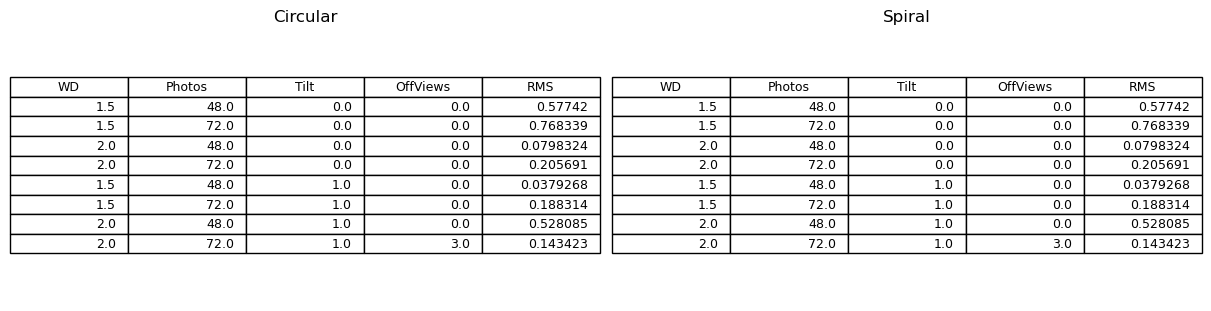

In [99]:
# Filter to show only the Circular Pattern data
dsift_ptn1_df = dsift_df[dsift_df['Pattern'] == "Circular"]

# Filter to show only the Circular Pattern data
dsift_ptn2_df = dsift_df[dsift_df['Pattern'] == "Spiral"]

# Plot them side by side on a table
plot2_DFs( dsift_ptn1_df, dsift_ptn2_df, ["Circular", "Spiral"], "Pattern" )

# display(disft_ptn1_df.describe()) 
# display(disft_ptn2_df.describe())


Text(0.5, 1.0, 'Misplaced Views vs RMS')

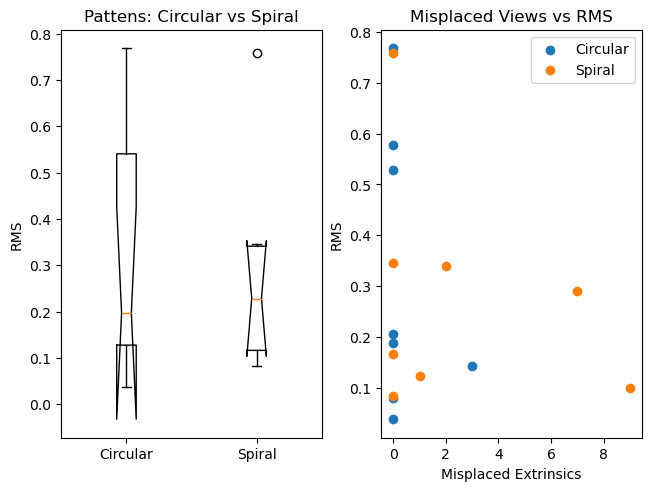

In [100]:
patternRMS = [disft_ptn1_df["RMS"].values, disft_ptn2_df["RMS"].values]
labels = ["Circular", "Spiral"]

fig, axs = plt.subplots(1,2, layout="constrained")
axs[0].boxplot(patternRMS, vert=True, notch=True, labels=labels)
axs[0].set_title("Pattens: Circular vs Spiral")
axs[0].set_ylabel("RMS")

axs[1].scatter( disft_ptn1_df["OffViews"].values, disft_ptn1_df["RMS"].values  )
axs[1].scatter( disft_ptn2_df["OffViews"].values, disft_ptn2_df["RMS"].values  )
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].legend(labels)
axs[1].set_title("Misplaced Views vs RMS")


### Pattern Inferences

.
.
.


## Analysis by Working Distance

Working distance has only 2 levels, 1.5R and 2.0R. R is the radius at which the camera is able to accomodate the longer side of the target object within its horizontal FOV. 1.5R is therefore 1.5 times the radius R while 2.0R is twice the radius R. The 2 distances will be discretised as follows:
    
    - 1.5R => Close
    - 2R => Far

The Question: Which is better being, Far or Close?

,WD,Photos,Tilt,OffViews,RMS
count,8.0,8.00000,8.000000,8.000000,8.000000
mean,1.5,60.00000,0.500000,1.250000,0.277732
std,0.0,12.82854,0.534522,3.150964,0.265866
min,1.5,48.00000,0.000000,0.000000,0.037927
25%,1.5,48.00000,0.000000,0.000000,0.095015
50%,1.5,60.00000,0.500000,0.000000,0.155158
75%,1.5,72.00000,1.000000,0.250000,0.403780
max,1.5,72.00000,1.000000,9.000000,0.768339


,WD,Photos,Tilt,OffViews,RMS
count,8.0,8.00000,8.000000,8.000000,8.000000
mean,2.0,60.00000,0.500000,1.500000,0.313972
std,0.0,12.82854,0.534522,2.507133,0.227573
min,2.0,48.00000,0.000000,0.000000,0.079832
25%,2.0,48.00000,0.000000,0.000000,0.160121
50%,2.0,60.00000,0.500000,0.000000,0.248208
75%,2.0,72.00000,1.000000,2.250000,0.386676
max,2.0,72.00000,1.000000,7.000000,0.758792


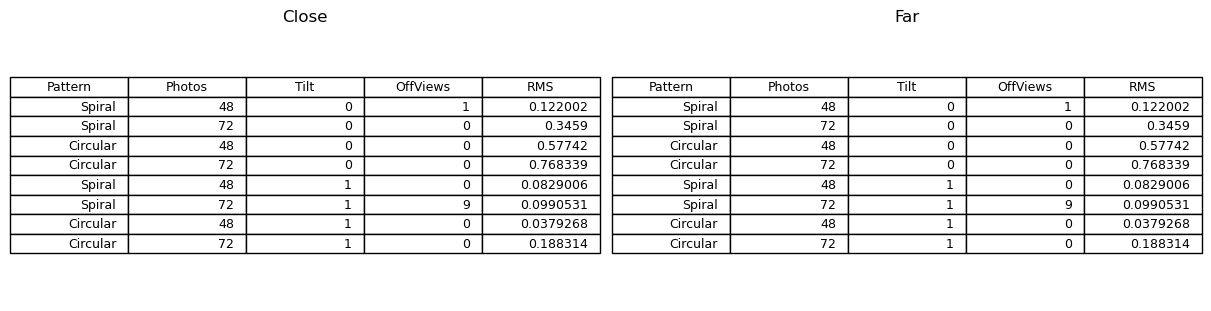

In [101]:
# Filter to show only the Circular Pattern data
disft_wd1_df = dsift_df[dsift_df['WD'] == 1.5]

# Filter to show only the Circular Pattern data
disft_wd2_df = dsift_df[dsift_df['WD'] == 2.0]

# Plot them side by side on a table
plot2_DFs( disft_wd1_df, disft_wd2_df, ["Close", "Far"], "WD" )

# C
display(disft_wd1_df.describe()) 
display(disft_wd2_df.describe())


Text(0.5, 1.0, 'Misplaced Extrinsics vs RMS')

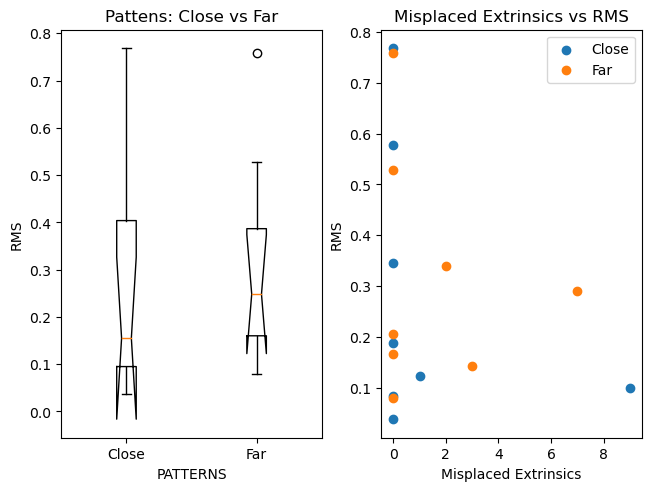

In [102]:
WD_RMS = [disft_wd1_df["RMS"].values, disft_wd2_df["RMS"].values]
labels = ["Close", "Far"]

fig, axs = plt.subplots(1,2, layout="constrained")
axs[0].boxplot(WD_RMS, vert=True, notch=True, labels=labels)
axs[0].set_title("Pattens: Close vs Far")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("PATTERNS")

axs[1].scatter( disft_wd1_df["OffViews"].values, disft_wd1_df["RMS"].values  )
axs[1].scatter( disft_wd2_df["OffViews"].values, disft_wd2_df["RMS"].values  )
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].legend(labels)
axs[1].set_title("Misplaced Extrinsics vs RMS")


### Working Distance Inferences

.
.
.

## Analysis by number of Photos

The Photos factor had 2 level with the first having 48 photos and the second 72. The choice for each level was arbitrary. The levels can be discretised as Less(48) and More(72).

The Question: Does more photos mean better results?

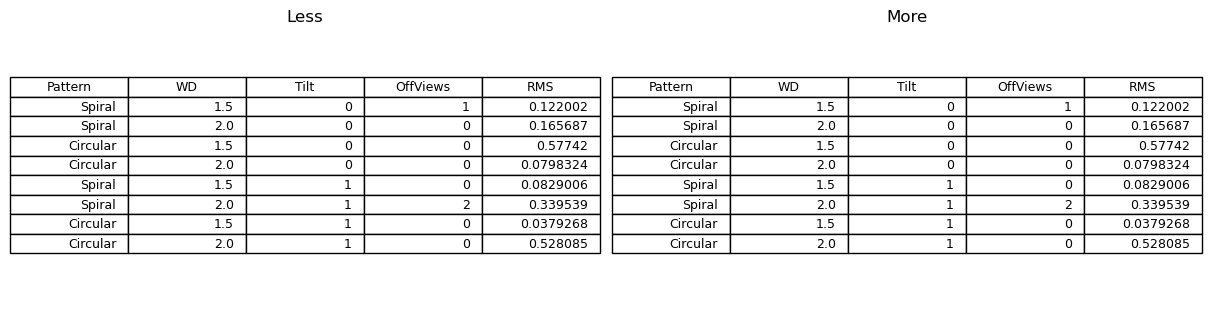

In [103]:
# Filter to show only the Circular Pattern data
disft_numPh1_df = dsift_df[dsift_df['Photos'] == 48]

# Filter to show only the Circular Pattern data
disft_numPh2_df = dsift_df[dsift_df['Photos'] == 72]

labels = ["Less", "More"]

# Plot them side by side on a table
plot2_DFs( disft_numPh1_df, disft_numPh2_df, labels, "Photos" )

# display(disft_wd1_df.describe()) 
# display(disft_wd2_df.describe())


Text(0.5, 1.0, 'Misplaced Views vs RMS')

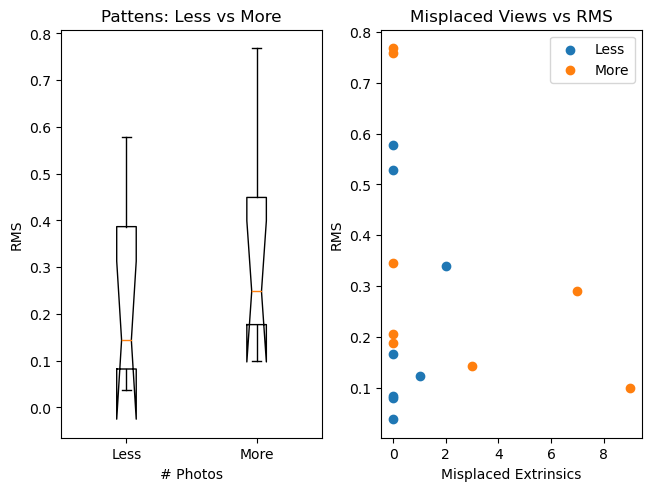

In [104]:
Photos_RMS = [disft_numPh1_df["RMS"].values, disft_numPh2_df["RMS"].values]

fig, axs = plt.subplots(1,2, layout="constrained")
axs[0].boxplot(Photos_RMS, vert=True, notch=True, labels=labels)
axs[0].set_title("Pattens: Less vs More")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("# Photos")

axs[1].scatter( disft_numPh1_df["OffViews"].values, disft_numPh1_df["RMS"].values  )
axs[1].scatter( disft_numPh2_df["OffViews"].values, disft_numPh2_df["RMS"].values  )
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].legend(labels)
axs[1].set_title("Misplaced Views vs RMS")


### Number of Photos Inferences

.
.
.


## Analysis by Tilt

Tilt is whereby the camera **Looks At** the "Centroid" of the target object regardless of its elevation. In the context of Spatial Mechanics, this can be described as the "Pitch" of the camera. For a cirular pattern, there is only ever 2 pitch angles for the each elevation. As for the Spiral Pattern, there are as many pitch angles as there are elevations.

The Question: Does Tilt affect the Resultant reconstruction?

,WD,Photos,Tilt,OffViews,RMS
count,8.0,8.00000,8.000000,8.000000,8.000000
mean,1.5,60.00000,0.500000,1.250000,0.277732
std,0.0,12.82854,0.534522,3.150964,0.265866
min,1.5,48.00000,0.000000,0.000000,0.037927
25%,1.5,48.00000,0.000000,0.000000,0.095015
50%,1.5,60.00000,0.500000,0.000000,0.155158
75%,1.5,72.00000,1.000000,0.250000,0.403780
max,1.5,72.00000,1.000000,9.000000,0.768339


,WD,Photos,Tilt,OffViews,RMS
count,8.0,8.00000,8.000000,8.000000,8.000000
mean,2.0,60.00000,0.500000,1.500000,0.313972
std,0.0,12.82854,0.534522,2.507133,0.227573
min,2.0,48.00000,0.000000,0.000000,0.079832
25%,2.0,48.00000,0.000000,0.000000,0.160121
50%,2.0,60.00000,0.500000,0.000000,0.248208
75%,2.0,72.00000,1.000000,2.250000,0.386676
max,2.0,72.00000,1.000000,7.000000,0.758792


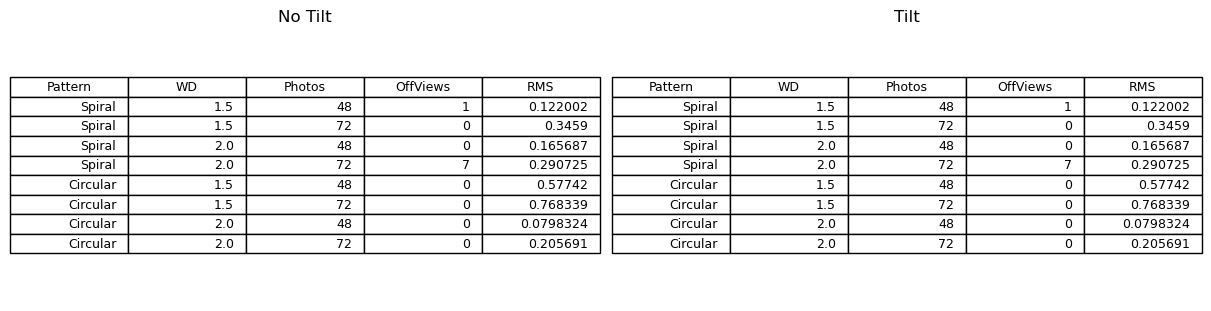

In [105]:
# Filter to show only the Circular Pattern data
disft_tilt0_df = dsift_df[dsift_df['Tilt'] == 0]

# Filter to show only the Circular Pattern data
disft_tilt1_df = dsift_df[dsift_df['Tilt'] == 1]

labels = ["No Tilt", "Tilt"]

# Plot them side by side on a table
plot2_DFs( disft_tilt0_df, disft_tilt1_df, labels, "Tilt" )

display(disft_wd1_df.describe()) 
display(disft_wd2_df.describe())


Text(0.5, 1.0, 'Misplaced Views vs RMS')

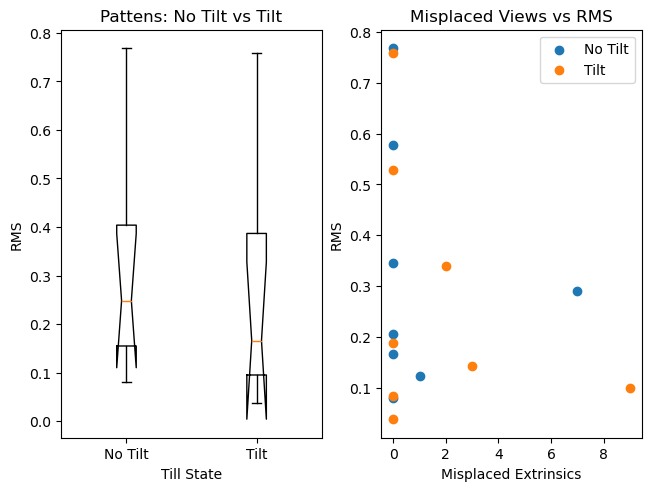

In [106]:
Photos_RMS = [disft_tilt0_df["RMS"].values, disft_tilt1_df["RMS"].values]

fig, axs = plt.subplots(1,2, layout="constrained")
axs[0].boxplot(Photos_RMS, vert=True, notch=True, labels=labels)
axs[0].set_title("Pattens: No Tilt vs Tilt")
axs[0].set_ylabel("RMS")
axs[0].set_xlabel("Till State")

axs[1].scatter( disft_tilt0_df["OffViews"].values, disft_tilt0_df["RMS"].values  )
axs[1].scatter( disft_tilt1_df["OffViews"].values, disft_tilt1_df["RMS"].values  )
axs[1].set_ylabel("RMS")
axs[1].set_xlabel("Misplaced Extrinsics")
axs[1].legend(labels)
axs[1].set_title("Misplaced Views vs RMS")


### Tilt Inferences

.
.
.
